# Baseline 3 — XGBoost + hand-built neighbor features

The same model as baseline 2, plus **per-layer network features**, all measured
at or before time *t*. If message-passing GNNs are to earn their complexity,
they must beat this: a strong tabular learner that already sees hand-crafted
summaries of each network layer.

Per layer (suppliers, customers, shared-creditor, board interlocks, 4-digit
industry, 3-digit industry, same state — ownership is empty in the current data):

| Feature | Meaning |
|---|---|
| `<layer>_degree` | number of live neighbors at *t* |
| `<layer>_nbr_def_cnt` / `_share` | neighbor default events in the 4 quarters up to *t* (contagion signal) |
| `<layer>_nbr_<stat>` | mean of neighbor distress stats: `altman_z`, `roa`, `debt_to_assets`, `ret_12m`, `volatility_12m`, `log_mktcap` |

Because defaulting firms drop out of the panel, neighbor defaults are anchored
at the **defaulter's last active quarter** and flagged for the four quarters
after the event — see [`neighbor_features.py`](neighbor_features.py); features
are cached to `data/clean/neighbor_features_quarterly.parquet`.

Same tuning protocol as baseline 2, so any performance gap is attributable to
the network information.

**Training protocol: walk-forward.** Every model is trained with an expanding
window and annual refit anchors 2007–2025 ([`walk_forward.py`](walk_forward.py)):
the model scoring calendar year Y is fit only on rows whose h-quarter label
window closed before Y began (`datadate ≤ Y-01-01 − horizon days`), per horizon
h = 1..8. Scores therefore exist for 2007+ only, and all of 2007–2025 is
out-of-sample. Scores are cached per model/horizon
(`results/models/wf_scores_<model>.parquet`); delete a cache to retrain.

Labels for h ∈ {1, 4, 8} come from phase4; intermediate horizons are rebuilt
with the identical rule and validated at load time. Each horizon's evaluation
sample is right-censored separately. Reported windows: **val-era 2007–2012**
and **test 2013–2025** (for XGBoost models, hyperparameters and tree counts are
selected on 2007–2012, so treat that window accordingly; 2013+ is untouched by
any selection).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import baseline_utils as bu
import neighbor_features as nf
import walk_forward as wf

panel = bu.load_panel()
nbr = nf.build_neighbor_features(panel)   # slow on first run; cached afterwards
nbr_cols = nf.neighbor_feature_columns(nbr)
print(f'{len(nbr_cols)} neighbor features across {len(nf.NEIGHBOR_FEATURE_PREFIXES)} layers')

panel = panel.merge(nbr, on=['gvkey', 'year', 'quarter'], how='left')
FEATURES = bu.XGB_FEATURES + nbr_cols
print(f'{len(FEATURES)} total features')

63 neighbor features across 7 layers


115 total features


In [2]:
# Layer coverage: share of firm-quarters with at least one neighbor, by split
deg_cols = [c for c in nbr_cols if c.endswith('_degree')]
coverage = panel.groupby('split')[deg_cols].apply(lambda g: (g > 0).mean())
coverage.loc[['train', 'val', 'test']].T.round(3)

split,train,val,test
supply_cust_degree,0.171,0.175,0.139
supply_supp_degree,0.086,0.110,0.097
creditor_degree,0.069,0.131,0.137
board_degree,0.277,0.514,0.540
ind4_degree,0.959,0.952,0.904
ind3_degree,0.960,0.956,0.907
state_degree,0.931,0.867,0.794


In [3]:
# Hyperparameter search (20 draws) at the primary 4q horizon, early stopping on
# val PR-AUC; cached to a trials CSV (delete it to re-run). All walk-forward
# refits reuse the winning configuration — re-tuning at every anchor x horizon
# would be ~150x the search cost, and one configuration keeps the term
# structure and the anchors comparable.
col = bu.label_col(bu.PRIMARY_HORIZON)
m4 = bu.horizon_mask(panel, bu.PRIMARY_HORIZON)
tr4 = panel[m4 & (panel['split'] == 'train')]
va4 = panel[m4 & (panel['split'] == 'val')]

trials_path = bu.RESULTS / 'xgb_neighbor_features_trials.csv'
if trials_path.exists():
    trials_df = pd.read_csv(trials_path).sort_values('val_pr_auc', ascending=False)
    print(f'loaded {len(trials_df)} cached tuning trials from {trials_path.name}')
else:
    trials, _ = bu.xgb_random_search(
        tr4[FEATURES], tr4[col].values, va4[FEATURES], va4[col].values,
        n_iter=20, seed=42)
    trials_df = pd.DataFrame(trials).sort_values('val_pr_auc', ascending=False)
    trials_df.to_csv(trials_path, index=False)
best = trials_df.iloc[0].to_dict()
trials_df.round(4).head(10)

loaded 20 cached tuning trials from xgb_neighbor_features_trials.csv


,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_lambda,scale_pos_weight,best_iteration,val_roc_auc,val_pr_auc
0,7,0.0171,5.0,0.6360,0.8612,0.8390,1.0000,255,0.9199,0.2098
1,8,0.0454,5.0,0.6758,0.5650,0.8941,1.0000,61,0.9237,0.2067
2,3,0.0266,10.0,0.6123,0.7184,0.2686,1.0000,371,0.9012,0.2038
3,7,0.1339,50.0,0.7550,0.6442,2.3173,16.8557,13,0.9095,0.2030
4,4,0.0797,50.0,0.9291,0.7217,0.2848,1.0000,102,0.8922,0.2020
5,7,0.0457,50.0,0.9060,0.8174,1.2798,16.8557,95,0.9166,0.2003
6,4,0.0439,20.0,0.8275,0.5699,0.1695,16.8557,69,0.9046,0.1993
7,5,0.0264,20.0,0.7447,0.5438,0.1722,16.8557,29,0.8886,0.1960
8,5,0.0602,20.0,0.9136,0.8322,0.6498,16.8557,105,0.9018,0.1926
9,7,0.1008,20.0,0.7089,0.5482,6.3856,16.8557,40,0.9134,0.1925


In [4]:
# Tree count per horizon (one train/val early-stopping fit each; cached), then
# walk-forward scores for all horizons (cached per horizon, resumable)
n_trees = wf.select_n_trees(panel, 'xgb_neighbor_features', FEATURES, best)
print('trees per horizon:', n_trees)

scores = wf.build_xgb_wf_scores(panel, 'xgb_neighbor_features', FEATURES, best, n_trees)
panel = panel.merge(scores, on=['gvkey', 'datadate'], how='left')
panel = panel.rename(columns={f'xgb_neighbor_features_wf_h{h}': f'score_h{h}'
                              for h in bu.HORIZONS})

trees per horizon: {1: 84, 2: 147, 3: 157, 4: 256, 5: 197, 6: 223, 7: 226, 8: 482}
  xgb_neighbor_features_wf_h1: cached


  xgb_neighbor_features_wf_h2: cached


  xgb_neighbor_features_wf_h3: cached


  xgb_neighbor_features_wf_h4: cached


  xgb_neighbor_features_wf_h5: cached


  xgb_neighbor_features_wf_h6: cached


  xgb_neighbor_features_wf_h7: cached


  xgb_neighbor_features_wf_h8: cached


In [5]:
# Per-horizon metrics on the two out-of-sample windows
def wf_metrics(frame, h):
    mh = bu.horizon_mask(frame, h)
    out = {}
    for s in ['val', 'test']:
        sub = frame[mh & (frame['split'] == s)]
        out[s] = bu.evaluate_scores(sub[bu.label_col(h)].values,
                                    sub[f'score_h{h}'].values)
    return pd.DataFrame(out).T

metrics_by_h = {h: wf_metrics(panel, h) for h in bu.HORIZONS}
for h in bu.HORIZONS:
    m = metrics_by_h[h]
    print(f"h={h}q  test ROC-AUC={m.loc['test', 'roc_auc']:.4f}  "
          f"PR-AUC={m.loc['test', 'pr_auc']:.4f}  ({int(m.loc['test', 'n_pos'])} pos)")
print()
print('primary horizon (4q):')
metrics_by_h[bu.PRIMARY_HORIZON].round(4)

h=1q  test ROC-AUC=0.9851  PR-AUC=0.2985  (171 pos)
h=2q  test ROC-AUC=0.9819  PR-AUC=0.3344  (423 pos)
h=3q  test ROC-AUC=0.9745  PR-AUC=0.3177  (710 pos)
h=4q  test ROC-AUC=0.9723  PR-AUC=0.2947  (1031 pos)
h=5q  test ROC-AUC=0.9609  PR-AUC=0.2607  (1377 pos)
h=6q  test ROC-AUC=0.9536  PR-AUC=0.2564  (1720 pos)
h=7q  test ROC-AUC=0.9444  PR-AUC=0.2493  (2047 pos)
h=8q  test ROC-AUC=0.9374  PR-AUC=0.2536  (2360 pos)

primary horizon (4q):


,n,n_pos,base_rate,roc_auc,pr_auc,capture_top1pct,capture_top5pct,capture_top10pct
val,173027.0,826.0,0.0048,0.9272,0.2152,0.4237,0.7482,0.8366
test,322530.0,1031.0,0.0032,0.9723,0.2947,0.5664,0.8594,0.9224


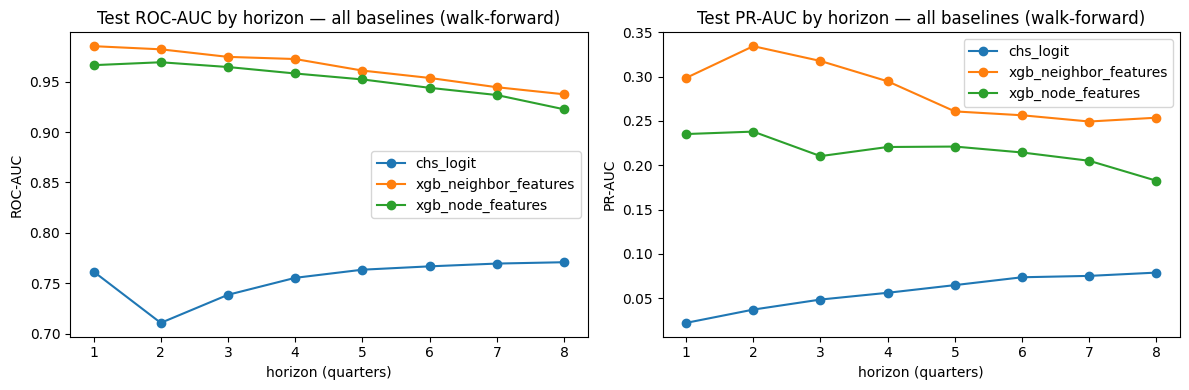

model,chs_logit,xgb_neighbor_features,xgb_node_features
horizon,,,
1,0.7618,0.9851,0.9662
2,0.7109,0.9819,0.9691
3,0.7387,0.9745,0.9644
4,0.7555,0.9723,0.9580
5,0.7636,0.9609,0.9521
6,0.7669,0.9536,0.9438
7,0.7697,0.9444,0.9367
8,0.7710,0.9374,0.9225


In [6]:
# Head-to-head across all three baselines, at every horizon (test, walk-forward)
rows = []
for h in bu.HORIZONS:
    rows.append({'horizon': h, 'model': 'xgb_neighbor_features',
                 'roc_auc': metrics_by_h[h].loc['test', 'roc_auc'],
                 'pr_auc': metrics_by_h[h].loc['test', 'pr_auc']})
for name in ['chs_logit', 'xgb_node_features']:
    p = bu.RESULTS / f'{name}_metrics.json'
    if not p.exists():
        continue
    m = json.load(open(p))['metrics']
    for h in bu.HORIZONS:
        rows.append({'horizon': h, 'model': name,
                     'roc_auc': m[f'h{h}']['test']['roc_auc'],
                     'pr_auc': m[f'h{h}']['test']['pr_auc']})
comp = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, name in zip(axes, ['roc_auc', 'pr_auc'], ['ROC-AUC', 'PR-AUC']):
    for model, grp in comp.groupby('model'):
        ax.plot(grp['horizon'], grp[metric], marker='o', label=model)
    ax.set_xlabel('horizon (quarters)'); ax.set_ylabel(name); ax.legend()
    ax.set_title(f'Test {name} by horizon — all baselines (walk-forward)')
plt.tight_layout(); plt.show()
comp.pivot(index='horizon', columns='model', values='roc_auc').round(4)

network features in the top 30 by gain: 8 / 30


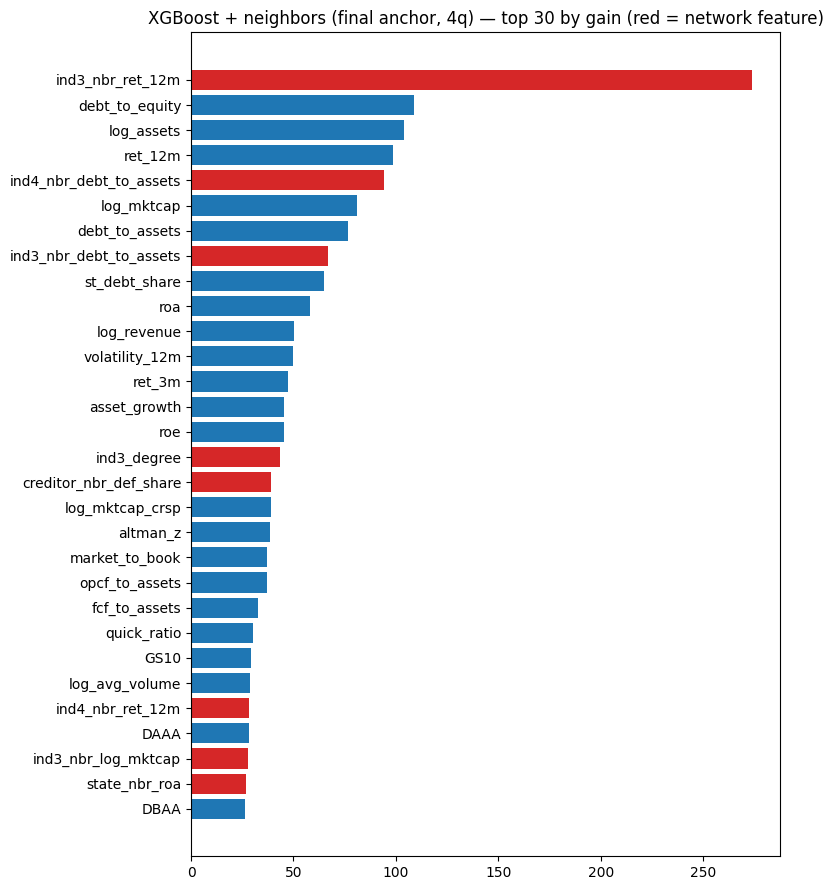

In [7]:
# Representative model for inspection: the final anchor (2025) at 4q —
# trained on everything a 2025 deployment could have seen
import xgboost as xgb

cutoff = wf.embargo_cutoff(wf.ANCHORS[-1], bu.PRIMARY_HORIZON)
tr = panel[(panel['year'] >= wf.TRAIN_START) & (panel['datadate'] <= cutoff)]
final_model = xgb.XGBClassifier(
    n_estimators=n_trees[bu.PRIMARY_HORIZON], tree_method='hist',
    eval_metric='aucpr', n_jobs=-1, random_state=42,
    max_depth=int(best['max_depth']), learning_rate=best['learning_rate'],
    min_child_weight=best['min_child_weight'], subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'], reg_lambda=best['reg_lambda'],
    scale_pos_weight=best['scale_pos_weight'])
final_model.fit(tr[FEATURES], tr[bu.LABEL_COL].values, verbose=False)
final_model.save_model(str(bu.RESULTS / 'xgb_neighbor_features_final_anchor_4q.ubj'))
gain = pd.Series(final_model.get_booster().get_score(importance_type='gain'))
gain = gain.sort_values(ascending=False)

is_nbr = gain.index.isin(nbr_cols)
print(f'network features in the top 30 by gain: {is_nbr[:30].sum()} / 30')
top = gain.head(30)[::-1]
colors = ['#d62728' if c in nbr_cols else '#1f77b4' for c in top.index]
fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(top.index, top.values, color=colors)
ax.set_title('XGBoost + neighbors (final anchor, 4q) — top 30 by gain '
             '(red = network feature)')
plt.tight_layout(); plt.show()

In [8]:
# Gain attributable to each layer (final-anchor 4q model)
layer_gain = {}
for p in nf.NEIGHBOR_FEATURE_PREFIXES:
    layer_gain[p] = gain[gain.index.str.startswith(p + '_')].sum()
layer_gain['own-firm features'] = gain[~gain.index.isin(nbr_cols)].sum()
share = pd.Series(layer_gain).sort_values(ascending=False) / gain.sum()
share.round(4)

own-firm features    0.5265
ind3                 0.1506
ind4                 0.0843
creditor             0.0600
board                0.0521
state                0.0519
supply_supp          0.0407
supply_cust          0.0339
dtype: float64

In [9]:
score_cols = [f'score_h{h}' for h in bu.HORIZONS]
out = bu.save_results(
    'xgb_neighbor_features',
    {f'h{h}': {s: metrics_by_h[h].loc[s].to_dict() for s in ['val', 'test']}
     for h in bu.HORIZONS},
    predictions=panel[['gvkey', 'datadate', 'split'] + score_cols],
    extra={'protocol': 'walk-forward, annual anchors 2007-2025, label embargo',
           'best_params': {k: best[k] for k in
                           ['max_depth', 'learning_rate', 'min_child_weight',
                            'subsample', 'colsample_bytree', 'reg_lambda',
                            'scale_pos_weight']},
           'n_trees_per_horizon': {str(h): n_trees[h] for h in bu.HORIZONS},
           'n_features': len(FEATURES),
           'n_neighbor_features': len(nbr_cols)},
)
print('saved ->', out)

saved -> /Users/GabrielReisen/Desktop/Credit Contagion Network/results/models/xgb_neighbor_features_metrics.json
